In [1]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xarray as xr

import parcels

from src.saws_functions import sarg_grid_from_sat  # noqa: E402

/tmp/ipykernel_3135207/472112538.py:8: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
end_images = [
    {
        'image_name': "../SaWSdata/C20242082024214.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -63.0, -38.0],
    },
    {
        'image_name': "../SaWSdata/C20242082024214.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -38.0, -11.5],
    },
    {
        'image_name': "../SaWSdata/C20242082024214.1KM.ECARIB.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [23.0, 10.0, -75.0, -60.0],
    },
]
sarg_final_lon, sarg_final_lat, _ = sarg_grid_from_sat(end_images, coarse=True)

In [3]:
df = parcels.read_particlefile("Simulations/Simulation_Satellite_kN_0.001.parquet")

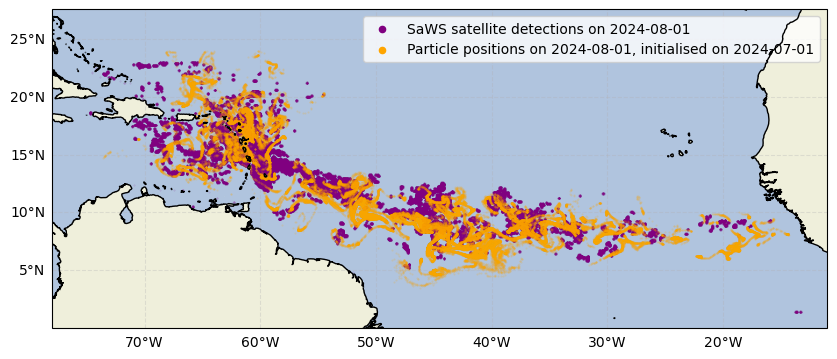

In [4]:
fig = plt.figure(figsize = (10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor('lightsteelblue')
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

first_time = df.select(pl.col("time").min()).item()
last_time = df.select(pl.col("time").max()).item()
last_locations = df.filter(pl.col("time") == last_time)

satplot = ax.scatter(sarg_final_lon, sarg_final_lat, s = 0.11, c='purple', label='SaWS satellite detections on 2024-08-01',zorder=6, alpha=0.2)
label = f'Particle positions on {last_time.strftime("%Y-%m-%d")}, initialised on {first_time.strftime("%Y-%m-%d")}'
eplot = ax.scatter(last_locations["lon"], last_locations["lat"], s = 0.2 ,color='orange', label = label ,zorder=7, alpha=0.2)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=8)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.set_extent([-78, -11, 0, 24])
leg = ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([20])
    handle.set_alpha(1.0)

fig.savefig('Figures/Figure2.png', bbox_inches='tight', dpi=300)

plt.show()